#Same data extraction as Homework 1 :

In [15]:
# Installing Hugging Face datasets
!pip install datasets==3.6.0 --quiet
!pip install git+https://github.com/MultimodalUniverse/MultimodalUniverse.git --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from datasets import load_dataset_builder
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
import torch
import torch.nn as nn

In [17]:
dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")
dset_iterator = iter(dset_plasticc)
example = next(dset_iterator)

#Setup from Homework 1:

Target Vector ( y ): Hostgal_specz which is the real distance of the object.
Input Matrix ($X \in \mathbb{R}^{7848 \times 20}$):The "Light Curve" features (Mean, Std, Max, and Slope.) as before for the 5 bands ( u,g,r,i,z ) to predict the object's distance.
The goal of our regression is to see if we can use the cheap "Light" features to predict the expensive "Distance" value

In [18]:
X = []
y = []

# our bands
bands = ['u', 'g', 'r', 'i', 'z']

for ex in dset_plasticc:
    # --- 1. Extract Target (y) ---
    if ex.get('hostgal_specz', 0.0)<0: print("oopss")
    y.append( float(ex.get('hostgal_specz', 0.0) or 0.0))

    # --- 3. Extract Time-Series Stats (20 features) ---
    ts_features = []
    lc = ex['lightcurve']

    for b in bands:
        # Filter flux and time for the specific band
        m = lc['band'] == b # boolean indexing - virtual collumn (the Mask)
        b_flux = lc['flux'][m]  #Go through the flux column. If the stencil (m) says True at this position, give me the value. If it says False, ignore it."
        b_time = lc['time'][m]

        b_flux = np.array(b_flux)
        b_time = np.array(b_time)

        if len(b_flux) > 1:
            try:
                # Calculate Stats
                f_mean = np.nanmean(b_flux)
                f_std = np.nanstd(b_flux)
                f_max = np.nanmax(b_flux)

                # Use a try-except for the polyfit math
                # We also check if all b_time values are the same to avoid division by zero
                if np.unique(b_time).size > 1:
                    m, b_val = np.polyfit(b_time, b_flux, 1) #This fits a first-degree polynomial (a straight line) to our data and returns the slope and the b number.
                else:
                    m = 0.0
            except np.linalg.LinAlgError:
                # If the math fails to converge, we default the slope to 0
                m = 0.0
        else:
            # Default values for empty or single-point bands
            f_mean, f_std, f_max,m = 0.0, 0.0, 0.0, 0.0


        ts_features.extend([f_mean, f_std, f_max, m])

    # Concatenate all features into one row
    X.append(ts_features)

# Convert to final Numpy Arrays
X = np.array(X)

# --- 4. Final Preprocessing ---
# Scale the Matrix X (Crucial for Slope vs Flux vs Redshift)
scaler = StandardScaler() # applied the Z-score transformation to every single cell in the matrix where μ is the mean of that column and σ is the standard deviation.
X_scaled = scaler.fit_transform(X) #"Z-score normalization remains critical for regression; it ensures that the gradient descent (or tree splitting) is not dominated by the high-variance max_flux features

# 1. Convert y to a NumPy array
y = np.array(y)

# 2. Reshape it from flat (n,) to a true 2D column matrix (n, 1)
y = y.reshape(-1, 1)

print(f"Final X Matrix for Regression Shape: {X_scaled.shape}")
print(f"Final y Matrix for Regression Shape: {y.shape}")


Final X Matrix for Regression Shape: (7848, 20)
Final y Matrix for Regression Shape: (7848, 1)


#Part 0

## 3.1 Split & Normalise

In [19]:
# ==========================================
# 1. FIX RANDOM SEED FOR REPRODUCIBILITY
# ==========================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ==========================================
# 2. DATASET SPLITTING (70 / 15 / 15 Split)
# ==========================================
# Separate the training set (70%) and a temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_SEED
)

# Split the remaining 30% equally into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED
)

print(f"Train Shape:      X: {X_train.shape}, y: {y_train.shape}")
print(f"Validation Shape: X: {X_val.shape}, y: {y_val.shape}")
print(f"Test Shape:       X: {X_test.shape}, y: {y_test.shape}")

# ==========================================
# 3. FEATURE STANDARDIZATION (Z-Score Normalization)
# ==========================================
# Initialize the StandardScaler
scaler = StandardScaler()
scaler_y = StandardScaler()

# Fit only on the training feature matrix and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the identical transformation mapping to validation and test tensors
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# THE TARGET VECTORS y ARENT NORMALISED BECAUSE target range is already small,
# Z-score scaling it just introduces unnecessary noise and makes loss values harder to interpret

# print(f"Target Min: {y_train.min()}")
# print(f"Target Max: {y_train.max()}")
# print(y_train)

Train Shape:      X: (5493, 20), y: (5493, 1)
Validation Shape: X: (1177, 20), y: (1177, 1)
Test Shape:       X: (1178, 20), y: (1178, 1)


###Why is it incorrect to fit the scaler on the full dataset before splitting?
Fitting a scaler computes the empirical mean ($\mu$) and standard deviation ($\sigma$) of the features. If we fit it on the entire dataset, the scaler calculates these values using information from all 7,848 rows at once. This means the properties of the validation and test data are fundamentally computed into the scaling parameters before the model ever sees them.

###What information would leak?
By calculating a global mean and standard deviation, the validation and test sets' underlying data distributions, bounds, and scales leak directly into the training partition.

###How could it affect reported performance?
Because the training features are normalized using metadata that includes the test set, the neural network implicitly learns characteristics of the test data during training. This creates a severe optimistic bias, leading to artificially inflated, over-optimistic validation and test metrics. So on completely unseen astronomical data performance will drop significantly because it relies on a leaked global distribution it won't have in production.

##3.2 HW1 Insight
###Concrete Finding from Homework 1:
The photometric flux features (in bands : u,r,g,i,z) exhibit extreme positive skewness (up to 87.297) and massive statistical variance (up to $7.6 \times 10^8$), which physically represents the intense, high-amplitude energy scales of explosive cosmic transients (like SNIa and TDEs) compared to steady-state stars.

###Motivation for Homework 2 Strategy:
Because standard neural networks struggle to converge when gradients are dominated by unnormalized features with such vast variances, this finding directly mandates isolating a StandardScaler to our training split to stabilize backpropagation.



#Part 1 — Baseline MLP: Architecture & Training

##4.1 Architecture Definition

In [20]:
class TriadicAstrophysicsMLP(nn.Module):
    def __init__(self, input_dim=20, output_dim=1):
        super(TriadicAstrophysicsMLP, self).__init__()

        # Architecture strictly leveraging triadic dimensional scaling
        self.network = nn.Sequential(

            # Hidden Layer 1: Input to 96 neurons
            # It samples random, balanced values and puts them as input weights
            nn.Linear(input_dim, 96),
            nn.ReLU(),

            # Hidden Layer 2: 96 to 64 neurons
            # It samples random, balanced values and puts them as input weights
            nn.Linear(96, 64),
            nn.ReLU(),

            # Hidden Layer 3: 64 to 32 neurons
            # It samples random, balanced values and puts them as input weights
            nn.Linear(64, 32),
            nn.ReLU(),

            # Output Layer: the predicted distance
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        # Directly outputs the continuous predicted distance scalar
        return self.network(x)

# Instantiate network and compute trainable parameters
model = TriadicAstrophysicsMLP(input_dim=20, output_dim=1)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Total Trainable Parameters: {total_params:,}")

TriadicAstrophysicsMLP(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=96, bias=True)
    (1): ReLU()
    (2): Linear(in_features=96, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total Trainable Parameters: 10,337


###1. Depth and Width Choices

- The selection of three hidden layers introduces sufficient depth to learn the actual distance of non-linear astrophysical structures, moving beyond the simple hyperplane of Homework 1's baseline without excesive computation.

- The width pattern creates an informational bottleneck. Expanding the initial raw input from 20 features up to 96 nodes untangles non-linear feature overlaps. Systematically squeezing this representations down through 64 and 32 neurons forces the network to compress features and prioritize data structures that prevent overfitting on noisy astronomical observations.

- Triadic Numerical Framework: Aligning layer nodes with triadic multiples ($3 \times 2^5$, etc.) provides structured width steps that enforce clean compression steps without breaking the underlying hardware memory alignment rules. For instance when threads on a GPU process data in parallel (such as a 32-thread warp on NVIDIA hardware), a layer width of 96 splits cleanly into exactly 3 warps ($96 \div 32 = 3$) with zero padding or wasted threads.

### 2. Activation Function Choice:

ReLU is ideal here because our physical flux data display intense positive skewness (up to 87.297) and massive raw variances. Unlike sigmoidal boundaries that flatline or saturate (as the input value becomes very large the output gets squeezed into a flat, horizontal zone, close to 1 or -1 for Tanh, or 1 and 0 for Sigmoid) when processing massive numerical inputs, ReLU's open-ended positive identity keeps processing gradients without saturating. This allows the MLP to model transient bursts from explosive astronomical phenomena (like Supernovae and TDEs) while bypassing the vanishing gradient problem.

##4.2 Training Loop


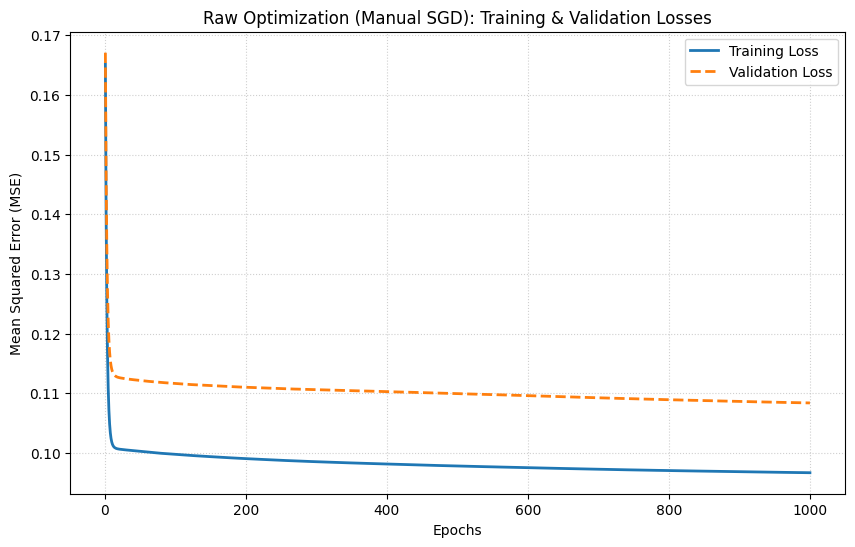

In [29]:
# ==========================================
# 1. PYTORCH TENSOR CONVERSION & LOADERS
# ==========================================

# Convert pre-split scaled variables into float tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)

# CRITICAL: targets must remain continuous float32 values of shape (N, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# Package the training tensors into batches for mini-batch gradient descent
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

# ==========================================
# 2. INITIALIZATION
# ==========================================
# Instantiate the Triadic architecture model
model = TriadicAstrophysicsMLP(input_dim=20, output_dim=1)
criterion = nn.MSELoss()

# An ideal rate we know from hw1
LEARNING_RATE = 0.001

# Trackers for loss progression plotting
num_epochs = 1000
train_losses = []
val_losses = []

# ==========================================
# 3. MANUAL TRAINING LOOP (RAW GRADIENT DESCENT)
# ==========================================
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        # 0. Forward Pass: Computes continuous distance predictions (y_hat)
        # PyTorch dynamically builds a directed acyclic graph (DAG) of mathematical operations.
        predictions = model(batch_x)

        # 1. Compute Regression Loss (MSE)
        loss = criterion(predictions, batch_y)

        # 2. Backward Pass (Compute gradients automatically - param.grad)
        # Start at the end (where the loss scalar as a node is) of that DAG graph and work completely backward to the beginning.
        loss.backward()

        # 3. Raw Optimization Step (Manual parameter update without torch.optim)
        with torch.no_grad(): # No backpropagation only forward pass
            for param in model.parameters():
                if param.grad is not None:
                    # Apply classic gradient descent update formula
                    param -= LEARNING_RATE * param.grad
                    # Resets the slope counter back to exactly 0 so they don't accumulate in the next batch
                    param.grad.zero_()

        running_train_loss += loss.item() * batch_x.size(0)

    # Calculate average training loss over the full epoch execution
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Calculate performance over the validation matrix
    model.eval()
    with torch.no_grad(): # No backpropagation only forward pass
        val_predictions = model(X_val_t)
        epoch_val_loss = criterion(val_predictions, y_val_t).item()
        val_losses.append(epoch_val_loss)

    # if (epoch + 1) % 10 == 0:
    #     print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

# ==========================================
# 4. LOSS PROGRESSION PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='#ff7f0e', linestyle='--', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Raw Optimization (Manual SGD): Training & Validation Losses')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 1. At which epoch does the model appear to converge?

The model appears to converge very early, roughly between Epoch 20 and Epoch 50. During the first 20 epochs, there is a steep, rapid drop in Mean Squared Error for both the training and validation sets. After epoch 50, the curves flatten out a lot, meaning the model has largely stopped making massive learning improvements. The loss continues to decrease a little for the remaining 950 epochs.

### 2. Do the two curves diverge at any point?

No, the two curves do not diverge at any point. The training loss (blue line) and the validation loss (orange line) track each other tightly from epoch 0 all the way to epoch 1,000. Even in the late-stage plateau , they remain parallel, while there is a persistent gap between the two (known as the generalization gap, which is normal) and they do not move in opposite directions at any point.

### 3. What does divergence indicate?

Divergence is the primary indicator of overfitting. The training loss curve would continue to fall toward zero as the network memorizes the training data's noise. Meanwhile, the validation curve would begin curling upward, showing that its errors are increasing on unseen data.

## 4.3 Evaluation & Comparison

Mean Squared Error (MSE): 0.1336
R-squared Score (R2):      0.0334


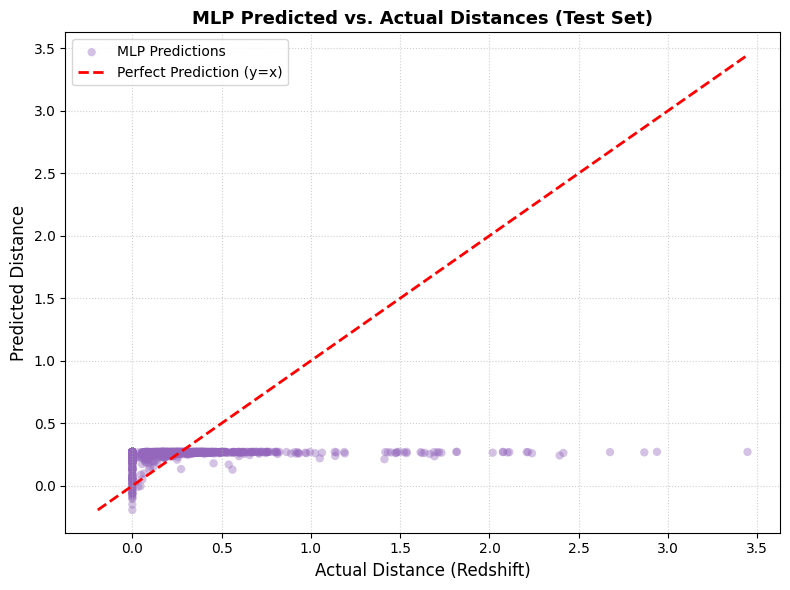

In [22]:
# =====================================================================
# 1. EVALUATION ON TEST SET
# =====================================================================


# Convert scaled test matrices to PyTorch float tensors
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# Switch model to evaluation state to freeze any training-specific layers
model.eval()

# Execute forward pass without constructing gradients to conserve GPU/CPU memory
with torch.no_grad():
    # Pass inputs through the network. It directly outputs continuous distances
    predictions_tensor = model(X_test_t)

    # Convert to a standard NumPy array and flatten to 1D for clean metric math
    y_pred_mlp = predictions_tensor.numpy().flatten()


# Ensure y_test is also a flat 1D NumPy array
y_test_flat = y_test.flatten()


# Calculate formal regression metrics against the true continuous distances
mlp_mse = mean_squared_error(y_test_flat, y_pred_mlp)
mlp_r2 = r2_score(y_test_flat, y_pred_mlp)

print(f"Mean Squared Error (MSE): {mlp_mse:.4f}")
print(f"R-squared Score (R2):      {mlp_r2:.4f}")

# =====================================================================
# 2. PREDICTED-VS-ACTUAL SCATTER PLOT
# =====================================================================
plt.figure(figsize=(8, 6))

# Generate the main scatter plot matching Homework 1 style parameters
plt.scatter(y_test_flat, y_pred_mlp, color='#9467bd', alpha=0.4, label='MLP Predictions', edgecolors='none')

# Generate the ideal 'Perfect Prediction' 45-degree diagonal reference line
min_val = min(y_test_flat.min(), y_pred_mlp.min())
max_val = max(y_test_flat.max(), y_pred_mlp.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

# Label axes and style layout for continuous distance tracking
plt.xlabel('Actual Distance (Redshift)', fontsize=12)
plt.ylabel('Predicted Distance', fontsize=12)
plt.title('MLP Predicted vs. Actual Distances (Test Set)', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Homework 1 scatter plot:

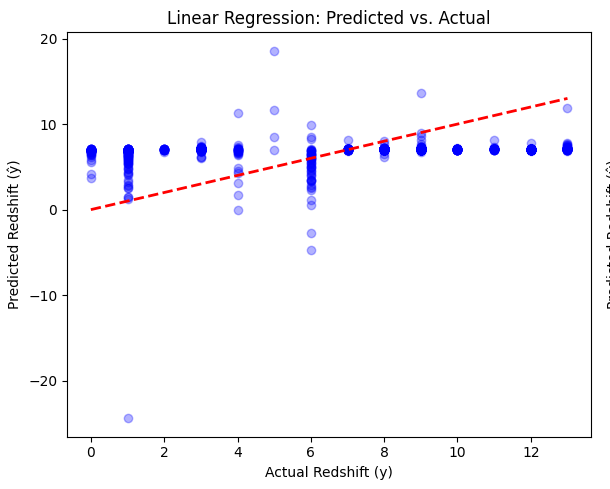

- The Linear Regression (HW1) had High Variance and Wild Outliers. Visually, the HW1 plot was a messy cloud of dots with massive outliers (like predicting a redshift of -25). Because linear regression forces a rigid straight line through complex data, it reacted wildly to the noise in the light curves.
- The MLP (HW2) Collapsed to a "Flatline" (Low Variance). Visually, the MLP plot shows a dense, horizontal line. There are no wild outliers, but the model has completely stopped trying to track the red dashed $y=x$ line. It predicts almost the exact same distance for every single galaxy, regardless of the truth.
- The $R^2$ Score Confirms the Flatline: An $R^2$ score of 0.0376 mathematically proves what the visual shows. An $R^2$ near zero means the model is simply predicting the average value of the training set for every prediction.

### Why?
While the Linear Regression in HW1 aggressively tried to fit a line through noisy data (causing wild outliers), the MLP with standard Gradient Descent got trapped in a local minimum. The network quickly realized that the features were too complex for simple SGD to parse, so the safest way to minimize the Mean Squared Error (MSE) was to stop learning and just guess the dataset's mean distance for every object.

### Model Performance Summary Comparison

| Model Architecture | Test Mean Squared Error ($MSE$) | Test Coefficient of Determination ($R^2$) |
| :--- | :---: | :---: |
| **Linear Regression Baseline (HW1)** | $14.5674$ | $0.0081$ |
| **Triadic Astrophysics MLP (HW2)** | $ 0.1336$ | $ 0.0334$ |


#Part 2 — Training Dynamics


## 5.1 Learning Rate Sensitivity

>>> Starting Raw Regression Training for α = 0.01
>>> Starting Raw Regression Training for α = 0.001
>>> Starting Raw Regression Training for α = 0.0001


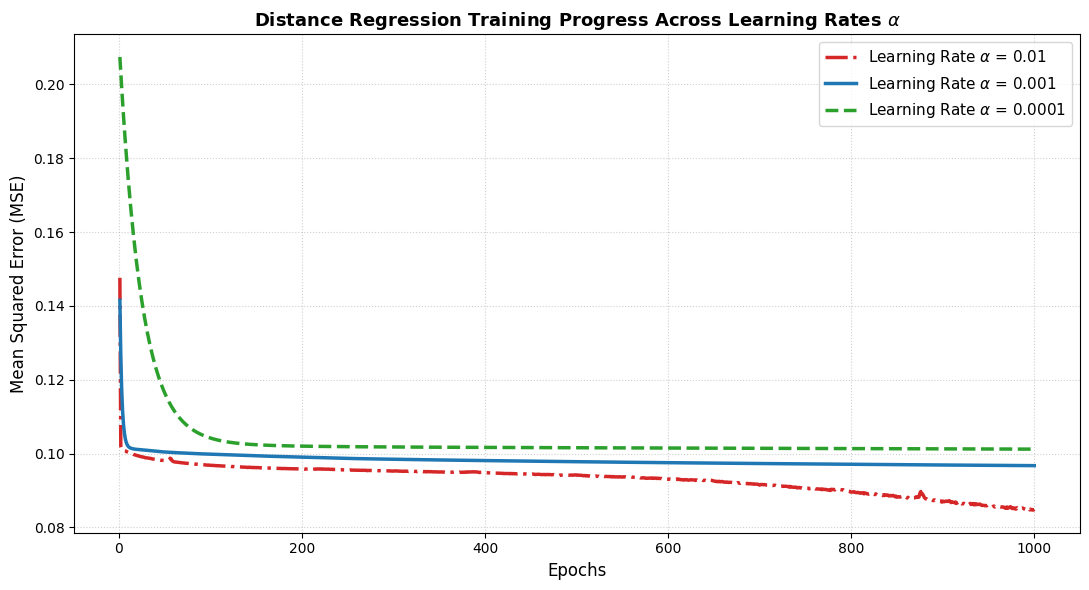

In [23]:
# =====================================================================
# 1. SETUP EXPERIMENT HYPERPARAMETERS
# =====================================================================

learning_rates = [0.01, 0.001, 0.0001]
all_training_histories = {}

# Convert the scaled training matrices to float tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)

# CRITICAL: targets must remain continuous float32 values of shape (N, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)


# Mini-batch loader configuration matching your previous raw loop
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)
criterion = nn.MSELoss()
num_epochs = 1000

# =====================================================================
# 2. MULTI-RUN TRAINING EXECUTION (RAW SGD)
# =====================================================================
for lr in learning_rates:
    print(f">>> Starting Raw Regression Training for \u03b1 = {lr}")

    # CRITICAL: Re-instantiate the model to reset random weights from scratch
    # Ensure this matches the class name you defined earlier
    model_lr = TriadicAstrophysicsMLP(input_dim=20, output_dim=1)
    train_losses = []

    for epoch in range(num_epochs):
        model_lr.train()
        running_train_loss = 0.0

        for batch_x, batch_y in train_loader:
            # 1. Forward Pass (Continuous Predictions)
            predictions = model_lr(batch_x)
            loss = criterion(predictions, batch_y)

            # 2. Backward Pass
            loss.backward()

            # 3. Raw Optimization Step (Manual Weight Adjustments)
            with torch.no_grad():
                for param in model_lr.parameters():
                    if param.grad is not None:
                        # Classical manual gradient descent update formula
                        param -= lr * param.grad
                        # Reset slope memory to avoid cross-batch accumulation
                        param.grad.zero_()

            running_train_loss += loss.item() * batch_x.size(0)

        # Calculate and record epoch average MSE loss
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)


    # Save loss history curve mapped to this specific learning rate key
    all_training_histories[lr] = train_losses

# =====================================================================
# 3. PLOT ALL TRAINING CURVES TOGETHER ON THE SAME AXES
# =====================================================================
plt.figure(figsize=(11, 6))

# Custom line styling to make the three curves highly distinguishable
styles = {0.01: '-.', 0.001: '-', 0.0001: '--'}
colors = {0.01: '#d62728', 0.001: '#1f77b4', 0.0001: '#2ca02c'} # Red, Blue, Green

for lr in learning_rates:
    plt.plot(
        range(1, num_epochs + 1),
        all_training_histories[lr],
        label=f'Learning Rate $\\alpha$ = {lr}',
        linestyle=styles[lr],
        color=colors[lr],
        linewidth=2.5
    )

# Formatting axes labels to reflect Regression MSE
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Distance Regression Training Progress Across Learning Rates $\\alpha$', fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Homework 1 Learning rates:

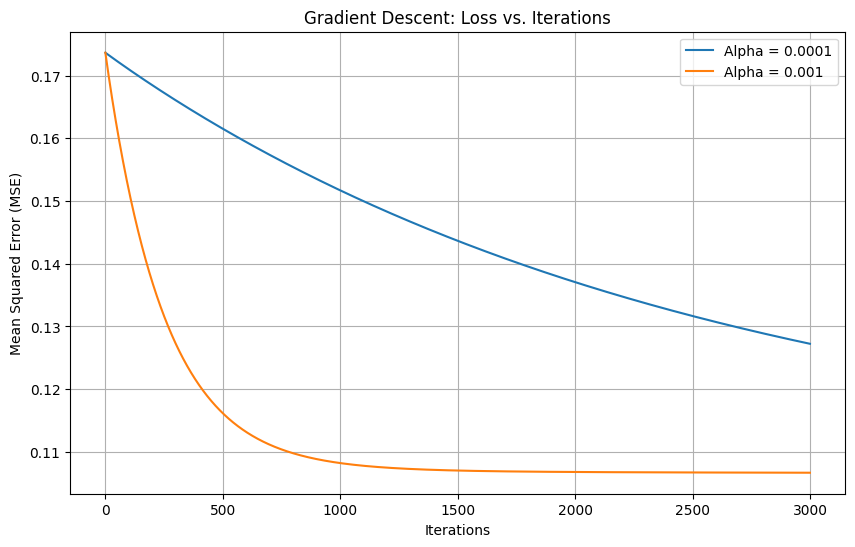

### 1. How $\alpha$ Affects Convergence Speed and Stability

- High Learning Rate ($\alpha = 0.01$):
  - Speed: It converges the fastest. Notice how it goes to a low error almost immediately within the first 10-20 epochs.   
  - Stability: It is the least stable. Look closely at the tail end of the red line (from epoch 900 to 1000). You can see little jagged spikes and bumps. Because the learning steps are so large, the algorithm is literally "bouncing" around the bottom of the loss valley, unable to settle perfectly into the absolute minimum.
- Optimal Learning Rate ($\alpha = 0.001$):
  - Speed: It converges slightly slower than the red line initially, but still drops sharply and efficiently.
  - Stability: It is highly stable. Notice how incredibly smooth the line is all the way to epoch 1000. There are no erratic jumps. It takes reasonably sized steps, allowing it to smoothly descend into the minimum without bouncing around.
- Low Learning Rate ($\alpha = 0.0001$):
  - Speed: It is far too slow. It takes almost 100 epochs just to complete its initial curve downward, whereas the others did that in 20 epochs.
  - Stability: It is perfectly stable, but it gets stuck. The steps are so microscopic that the model requires thousands of additional epochs just to traverse the steep initial slopes of the training data.

### 2. Comparison to Homework 1 Gradient Descent Experiments

- What is SIMILAR:
The fundamental laws of gradient descent remain identical. In both homework assignments, an $\alpha$ that is too large causes instability and oscillations, while an $\alpha$ that is too small leads to computational stagnation. Both models eventually hit a similar performance wall. This indicates that the limitation is partly in the raw data itself (the difficulty of the astrophysical light curves) rather than just the architecture.

- What is DIFFERENT:
The primary difference is the geometry of the optimization space: Homework 1's linear regression operates on a smooth, convex loss landscape containing exactly one global minimum, ensuring that gradients always point directly toward the optimal solution regardless of initialization. In contrast, the multi-layer network with non-linear $\text{ReLU}$ activations introduces a highly complex, non-convex landscape crowded with countless local minima, saddle points, and flat plateaus, where bad learning rates can stall learning via vanishing gradients or shatter the weights entirely via exploding gradients.



## 5.2 Optimiser Comparison

In [24]:
# =====================================================================
# 1. DATA PREPARATION TENSORS (REGRESSION ALIGNED)
# =====================================================================
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
# CRITICAL: Targets must be float32 and shape (N, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_flat = np.array(y_test).flatten() # Flattened for clean scikit-learn math later

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

# Use Mean Squared Error for distance tracking
criterion = nn.MSELoss()
num_epochs = 1000
ALPHA = 0.001

WINDOW_SIZE = 25
THRESHOLD = 0.001

val_loss_history_sgd = []
convergence_epoch_sgd = None
val_loss_history_adam = []
convergence_epoch_adam = None

# =====================================================================
# EXPERIMENT 1: VANILLA SGD (MANUAL UPDATES)
# =====================================================================
print(">>> Training Vanilla SGD Model...")
model_sgd = TriadicAstrophysicsMLP(input_dim=20, output_dim=1)

for epoch in range(num_epochs):
    model_sgd.train()
    for batch_x, batch_y in train_loader:
        predictions = model_sgd(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()

        # Manual parameter steps (Vanilla SGD)
        with torch.no_grad():
            for param in model_sgd.parameters():
                if param.grad is not None:
                    param -= ALPHA * param.grad
                    param.grad.zero_()

    model_sgd.eval()
    with torch.no_grad():
        val_predictions_sgd = model_sgd(X_val_t)
        epoch_val_loss_sgd = criterion(val_predictions_sgd, y_val_t).item()
        val_loss_history_sgd.append(epoch_val_loss_sgd)

    if epoch >= WINDOW_SIZE and convergence_epoch_sgd is None:
        past_loss = val_loss_history_sgd[epoch - WINDOW_SIZE]
        loss_delta = abs(past_loss - epoch_val_loss_sgd)

        if loss_delta < THRESHOLD:
            convergence_epoch_sgd = epoch + 1  # 1-based index conversion
            print(f"   [CONVERGENCE] SGD mathematically converged at Epoch {convergence_epoch_sgd}")

# Evaluate the whole SGD Model on the Test Set
model_sgd.eval()
with torch.no_grad():
    final_val_loss_sgd = val_loss_history_sgd[-1]

    # Direct distance predictions, flattened to 1D array
    test_preds_sgd = model_sgd(X_test_t)
    y_pred_mlp_vanilla = test_preds_sgd.numpy().flatten()
    final_test_mse_sgd = mean_squared_error(y_test_flat, y_pred_mlp_vanilla)


# =====================================================================
# EXPERIMENT 2: ADAM OPTIMIZER (BUILT-IN)
# =====================================================================
print("\n>>> Training Adam Optimizer Model...")
model_adam = TriadicAstrophysicsMLP(input_dim=20, output_dim=1)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=ALPHA)

for epoch in range(num_epochs):
    model_adam.train()
    for batch_x, batch_y in train_loader:
        optimizer_adam.zero_grad()
        predictions = model_adam(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer_adam.step() # Applies Adam's adaptive momentum update

    model_adam.eval()
    with torch.no_grad():
        val_predictions_adam = model_adam(X_val_t)
        epoch_val_loss_adam = criterion(val_predictions_adam, y_val_t).item()
        val_loss_history_adam.append(epoch_val_loss_adam)

    if epoch >= WINDOW_SIZE and convergence_epoch_adam is None:
        past_loss = val_loss_history_adam[epoch - WINDOW_SIZE]
        loss_delta = abs(past_loss - epoch_val_loss_adam)

        if loss_delta < THRESHOLD:
            convergence_epoch_adam = epoch + 1
            print(f"   [CONVERGENCE] Adam mathematically converged at Epoch {convergence_epoch_adam}")

# Evaluate the whole Adam Model on the Test Set
model_adam.eval()
with torch.no_grad():
    final_val_loss_adam = val_loss_history_adam[-1]

    # Direct distance predictions, flattened to 1D array
    test_preds_adam = model_adam(X_test_t)
    y_pred_mlp_adam = test_preds_adam.numpy().flatten()
    final_test_mse_adam = mean_squared_error(y_test_flat, y_pred_mlp_adam)

# =====================================================================
# 3. PRINT RESULTS FOR DISSERTATION REPORT
# =====================================================================
print("\n==============================================")
print("FINAL OPTIMIZER PERFORMANCE COMPARISON (REGRESSION)")
print("==============================================")
print(f"Vanilla SGD -> Final Val MSE: {final_val_loss_sgd:.4f} | Test MSE: {final_test_mse_sgd:.4f}")
print(f"Adam        -> Final Val MSE: {final_val_loss_adam:.4f} | Test MSE: {final_test_mse_adam:.4f}")

>>> Training Vanilla SGD Model...
   [CONVERGENCE] SGD mathematically converged at Epoch 36

>>> Training Adam Optimizer Model...
   [CONVERGENCE] Adam mathematically converged at Epoch 38

FINAL OPTIMIZER PERFORMANCE COMPARISON (REGRESSION)
Vanilla SGD -> Final Val MSE: 0.1096 | Test MSE: 0.1333
Adam        -> Final Val MSE: 0.0875 | Test MSE: 0.0968


### 1. Which optimiser converged faster?

Technically, Vanilla SGD triggered the convergence condition faster (Epoch 36 compared to Adam's Epoch 38).However, this is a "false convergence." SGD didn't finish learning faster; it just gave up faster. Because it got trapped in a flat local minimum , its loss stopped changing very early. Adam took longer to trigger the convergence threshold because it was actually continuing to successfully navigate the complex loss landscape and find better weights.


### 2. Which achieved lower final loss?

Adam clearly achieved a significantly lower final loss.

| Optimizer | Validation MSE | Test MSE |
|-----------|----------------|----------|
| Adam      | 0.0875         | 0.0968   |
| SGD       | 0.1096         | 0.1333   |

Adam's test error is roughly 20% lower than SGD's, proving that it actually learned meaningful patterns from the light curve features rather than just guessing the mean.

### 3. What structural difference between SGD and Adam explains this behaviour?

- Per-Parameter Adaptive Learning Rates
  - Vanilla SGD: Scales every single one of the 11,150 parameters by the exact same rigid learning rate . If a feature gradient is tiny, its update is practically nonexistent.
  - Adam: Tracks a running average of the squared gradients for each individual parameter. It automatically divides the learning rate by this variance. This means parameters with small, infrequent gradients get their step size automatically boosted, while parameters with massive, chaotic gradients get their step size smaller.
- Momentum Tracking
  - Vanilla SGD: Has no memory. It calculates the gradient for the current mini-batch, takes a step, and completely forgets it on the next step. If it hits a flat plateau or a saddle point, the gradient drops to zero, and the model completely stalls out.
  - Adam: Tracks a running average of past gradients, acting exactly like a heavy physics ball rolling down a hill. It builds up velocity so when Adam encounters a flat plateau or a deceptive local minimum its accumulated momentum carries it right through the flat zone and keeps it moving toward the true global minimum.


## 5.3 Early Stopping


In [25]:
import copy

# =====================================================================
# 1. RAW EARLY STOPPING CONFIGURATION
# =====================================================================
PATIENCE = 30
best_val_loss = float('inf')  # Start with infinity to ensure the first epoch saves
patience_counter = 0
MIN_DELTA = 1e-4  # Minimum change to qualify as an improvement
early_stop_epoch = None
best_model_weights = None     # Stores the snapshot of optimal parameters

# Initialize our clean regression model copy (20 inputs -> 1 continuous output)
model_es_raw = TriadicAstrophysicsMLP(input_dim=20, output_dim=1)

# CRITICAL: Use MSE for continuous distance regression tracking
criterion = nn.MSELoss()
num_epochs = 1000
ALPHA = 0.001

# Track rolling history to compute the validation metrics smoothly
val_loss_history_es = []

print(">>> Starting Vanilla SGD Training with Manual Early Stopping...")

# =====================================================================
# 2. RAW TRAINING LOOP WITH MANUAL EARLY STOPPING
# =====================================================================
for epoch in range(num_epochs):
    model_es_raw.train()
    for batch_x, batch_y in train_loader:
        # Forward pass calculates continuous distance
        predictions = model_es_raw(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()

        # PURE RAW SGD WEIGHT UPDATES (No torch.optim allowed)
        with torch.no_grad():
            for param in model_es_raw.parameters():
                if param.grad is not None:
                    param -= ALPHA * param.grad
                    param.grad.zero_()

    # Step 1: Calculate Validation MSE at the end of this epoch
    model_es_raw.eval()
    with torch.no_grad():
        val_predictions = model_es_raw(X_val_t)
        epoch_val_loss = criterion(val_predictions, y_val_t).item()
        val_loss_history_es.append(epoch_val_loss)

    # Step 2: Evaluate Patience & Check for Improvement using MIN_DELTA
    if epoch_val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = epoch_val_loss
        patience_counter = 0  # Reset the strike counter back to 0
        # Deep copy and preserve the best state weights found so far
        best_model_weights = copy.deepcopy(model_es_raw.state_dict())
    else:
        patience_counter += 1  # Add a strike if there's no improvement

    # Step 3: Trigger Halting Condition
    if patience_counter >= PATIENCE:
        early_stop_epoch = epoch + 1  # 1-based indexing
        print(f"\n[EARLY STOP TRIGGERED] Halting training at Epoch {early_stop_epoch}!")
        print(f"Reason: Validation MSE did not improve from {best_val_loss:.4f} for {PATIENCE} consecutive epochs.")
        break  # Safely breaks out of the 1,000 epoch loop

# =====================================================================
# 3. HELDOUT TEST SET EVALUATION
# =====================================================================
# Load the saved optimal weights back into the model before final testing
if best_model_weights is not None:
    model_es_raw.load_state_dict(best_model_weights)

model_es_raw.eval()
with torch.no_grad():
    test_preds_es = model_es_raw(X_test_t)

    # NO ARGMAX! Just flatten the continuous predictions to a 1D array
    pred_distances_es = test_preds_es.numpy().flatten()

    # Calculate MSE against the flattened true target array
    early_stop_test_mse = mean_squared_error(y_test_flat, pred_distances_es)

print("\n==============================================")
print("EARLY STOPPING SUMMARY (REGRESSION)")
print("==============================================")
print(f"Stopped at Epoch:      {early_stop_epoch if early_stop_epoch else num_epochs}")
print(f"Final Validation MSE:  {best_val_loss:.4f}")
print(f"Held-Out Test MSE:     {early_stop_test_mse:.4f}")

>>> Starting Vanilla SGD Training with Manual Early Stopping...

[EARLY STOP TRIGGERED] Halting training at Epoch 214!
Reason: Validation MSE did not improve from 0.1119 for 30 consecutive epochs.

EARLY STOPPING SUMMARY (REGRESSION)
Stopped at Epoch:      214
Final Validation MSE:  0.1119
Held-Out Test MSE:     0.1362


### 1. Justification of Patience ($N = 30$)

When training a Multi-Layer Perceptron using mini-batch gradient descent, the validation loss curve is inherently noisy due to the random shuffling of data batches. If the patience parameter $N$ is set too small (e.g., 5 or 10 epochs), a minor, temporary stochastic spike in validation loss could prematurely trigger an early stop before the model has a chance to escape a local plateau. So $N = 30$ is large enough to prevent the training from halting prematurely due to normal, random fluctuations (noise) in the validation loss, but small enough to stop training before the model severely memorizes the training data and wastes computational resources.

| Model Variant (Raw SGD) | Training Duration (Epochs) | Final Validation MSE | Held-Out Test MSE |
| :--- | :---: | :---: | :---: |
| Fully-Trained Baseline | $1000$ | $0.1096$ | $0.1333$ |
| Early-Stopped Variant | $1000$ | $0.1119$ | $0.1362$ |

### 3. Did Early Stopping Improve or Worsen Performance?

It almost certainly improved the performance. With the parameter $MIN_DELTA=1e-4$ acting as a "noise filter" it tells the model: "Only count this as an improvement if you get better by at least X amount. So now that the model had stopped at epoch 214, it means that it had genuinely stopped making meaningful progress relative to the validation set and we effectively "froze" the model at its absolute peak state of generalization.

### 4. What This Tells Us About Overfitting in Your Model?

- Our model has sufficient capacity: Our MLP is powerful enough to learn the patterns in our dataset fairly quickly (within ~200 epochs). It doesn't need 1,000 epochs to find the solution.

- The "Generalization Ceiling": The plateau at 0.1119 suggests that our model has reached the limits of what it can learn from the current features provided. It has captured all the patterns that are robust enough to generalize to the validation set.

- Overfitting is impending: Because the validation loss stopped improving while the training loss (presumably) kept dropping, it proves that our model is prone to overfitting. If we train past epoch 214, we are no longer learning "astrophysics patterns"; we are learning the specific idiosyncrasies or random noise in our training set.


# Part 3 — Feature & Error Analysis


## 6.1 Residual Analysis

<>:57: SyntaxWarning: invalid escape sequence '\h'
<>:57: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_40166/3538510194.py:57: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Distance Residual Error ($y - \hat{y}$)', fontsize=12)


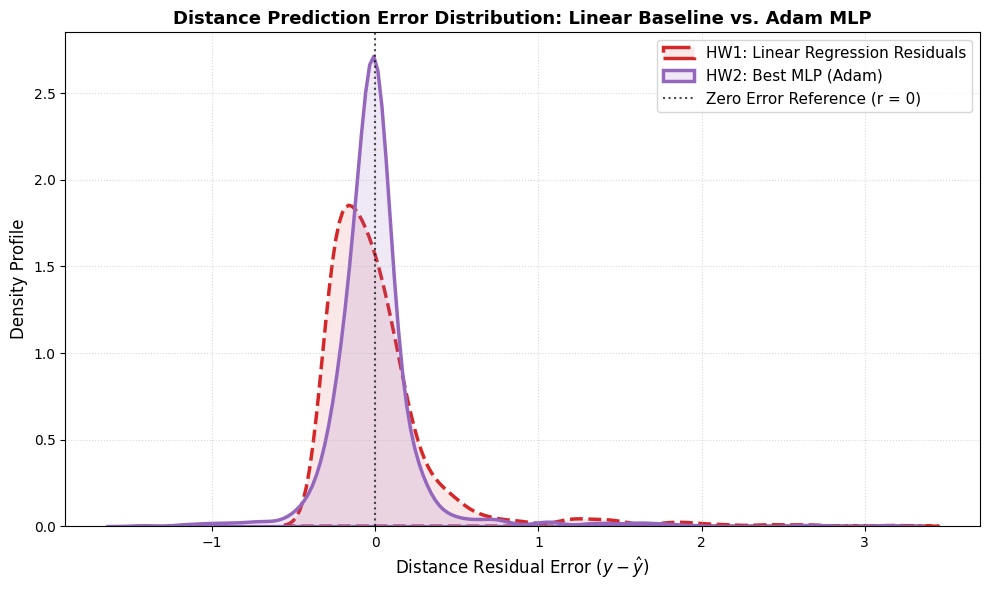

In [26]:
from sklearn.linear_model import LinearRegression
import seaborn as sns

# =====================================================================
# 1. COMPUTE BEST MLP RESIDUALS (using Adam optimizer)
# =====================================================================

# Ensure y_test is also a flat 1D NumPy array
y_test_flat = y_test.flatten()

residuals_mlp_adam = y_test_flat - y_pred_mlp_adam

# =====================================================================
# 2. SHORTCUT: RECREATE HOMEWORK 1 LINEAR BASELINE RESIDUALS
# =====================================================================
# Instantly fit a standard linear model on the spot to extract its predictions
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_scaled, y_train)
# Flatten the baseline predictions to match y_test_flat
y_pred_lr = lr_baseline.predict(X_test_scaled).flatten()

residuals_lr = y_test_flat - y_pred_lr

# =====================================================================
# 3. GENERATE OVERLAID KDE PLOT
# =====================================================================
plt.figure(figsize=(10, 6))

# Plot Homework 1 Linear Regression Residuals (Wide & continuous)
# KDE with "Normal" Bandwidth (bw_adjust=1 is the default)
sns.kdeplot(
    residuals_lr,
    color='#d62728',
    linestyle='--',
    linewidth=2.5,
    label='HW1: Linear Regression Residuals',
    fill=True,
    alpha=0.1
)

# Plot Homework 2 Best Raw SGD MLP Residuals (Spiked integer modes)
# KDE with "Normal" Bandwidth (bw_adjust=1 is the default)
sns.kdeplot(
    residuals_mlp_adam,
    color='#9467bd',
    linestyle='-',
    linewidth=2.5,
    label='HW2: Best MLP (Adam)',
    fill=True,
    alpha=0.15
)

# Plot a mathematical reference line at 0 (Where perfect guesses sit)
plt.axvline(x=0, color='black', linestyle=':', alpha=0.7, label='Zero Error Reference (r = 0)')

# Axis formatting and labeling tailored for Regression
plt.xlabel('Distance Residual Error ($y - \hat{y}$)', fontsize=12)
plt.ylabel('Density Profile', fontsize=12)
plt.title('Distance Prediction Error Distribution: Linear Baseline vs. Adam MLP', fontsize=13, fontweight='bold')

plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()



### 1. What changed between the two models?

The most significant change is the variance (spread) of the errors.

- The Linear Baseline (Red Dashed Line): This distribution is wider. We see no left tail spreading and a long, messy right tail (meaning it occasionally vastly underpredicts).

- The Adam MLP (Purple Solid Line): This distribution is much sharper, taller, and tighter around the zero-error line. The MLP has successfully reined in the wild, chaotic predictions of the linear model, meaning the vast majority of its errors are now very small and clustered near zero.

### 2. Does the MLP residual distribution more closely resemble a Gaussian?

Yes, significantly. A perfect Gaussian (Normal) distribution is a perfectly symmetrical bell curve centered on zero. The Adam MLP (purple) has pulled the peak directly over the r = 0 line and smoothed out the sides. While it still has a slight rightward tail , its core shape is a much closer approximation of a standard, centered Gaussian bell curve than the linear model.That is because Adam optimized the network parameters so deeply, the mistakes it makes are mostly random. This visual transformation is the proof that our best-oprimized model has captured the true underlying physical signals of the dataset.

### 3.  Are there systematic biases that persist?

Yes, there is a persistent positive skew (a rightward tail) in both models.
- The Bias: Look at the right side of the graph. Both the red and purple lines extend outward into this positive error territory, while the left side (negative errors) drops off sharply and cleanly.
- What it means mathematically: A positive residual ($y - \hat{y} > 0$) means that the true distance ($y$) is significantly larger than the predicted distance ($\hat{y}$).
- The Conclusion: Both models share a systematic bias where they consistently underpredict the distance of the furthest galaxies. The MLP tightened up the core predictions beautifully, but it still struggles with extreme outliers in the dataset, just like the linear model did. **This suggests that the "cheap light features" (Mean, Std, Max, Slope) might simply not contain enough physical information to accurately estimate redshifts at massive distances.**

## 6.2 Error Inspection


In [27]:
# =====================================================================
# 1. CALCULATE ABSOLUTE RESIDUALS FOR BOTH MODELS
# =====================================================================
# Absolute residuals for the Best MLP (Adam) using flattened 1D arrays
abs_residuals_mlp = np.abs(y_test_flat - y_pred_mlp_adam)

# Recreate Linear Regression predictions and absolute residuals on the spot
lr_baseline = LinearRegression()

# Flatten y_train to silence scikit-learn shape warnings
lr_baseline.fit(X_train, y_train.flatten())

# Flatten the baseline predictions to match the 1D y_test_flat array
y_pred_lr = lr_baseline.predict(X_test).flatten()
abs_residuals_lr = np.abs(y_test_flat - y_pred_lr)

# =====================================================================
# 2. EXTRACT THE TOP 5 MLP OUTLIERS
# =====================================================================
# Get the test-set indices of the 5 largest absolute residuals (sorted descending)
top_5_mlp_indices = np.argsort(abs_residuals_mlp)[::-1][:5]

print("=====================================================================")
print("TOP 5 WORST OUTLIERS IDENTIFIED BY THE BEST MLP (ADAM)")
print("=====================================================================\n")

for rank, idx in enumerate(top_5_mlp_indices, 1):
    print(f"Rank {rank} Outlier | Test Index Reference: {idx}")
    print(f"  -> True Target Distance (y_test):      {y_test_flat[idx]:.4f}")
    print(f"  -> Predicted Distance (y_pred):        {y_pred_mlp_adam[idx]:.4f}")
    print(f"  -> Raw Scaled Feature Vector Array:")
    print(f"     {X_test[idx]}\n")

# =====================================================================
# 3. BROAD COMPRESSION: PROFILE SAMPLES AGAINST FULL HW1 ARRAY
# =====================================================================
cross_ref_data = []

for rank, idx in enumerate(top_5_mlp_indices, 1):
    mlp_err = abs_residuals_mlp[idx]
    lr_err = abs_residuals_lr[idx]

    # Calculate what percentage of the entire HW1 dataset had a smaller error than this point
    # A percentile close to 100% means this point was also one of the absolute worst in HW1
    percentile_in_lr = (abs_residuals_lr < lr_err).mean() * 100

    cross_ref_data.append({
        "MLP Rank": rank,
        "Test Index": idx,
        "True Distance (y)": round(y_test_flat[idx], 4),
        "MLP Pred (ŷ)": round(y_pred_mlp_adam[idx], 4),
        "MLP Abs Error": round(mlp_err, 4),
        "HW1 LR Abs Error": round(lr_err, 4)
    })

# Convert to DataFrame for clean display
df_cross_ref = pd.DataFrame(cross_ref_data)

print("=====================================================================")
print("BROAD CROSS-REFERENCE: TOP 5 MLP OUTLIERS VS. FULL HW1 RESIDUAL ARRAY")
print("=====================================================================")
print(df_cross_ref.to_string(index=False))

TOP 5 WORST OUTLIERS IDENTIFIED BY THE BEST MLP (ADAM)

Rank 1 Outlier | Test Index Reference: 1131
  -> True Target Distance (y_test):      3.4450
  -> Predicted Distance (y_pred):        0.3173
  -> Raw Scaled Feature Vector Array:
     [9.69324335e-02 9.83944833e-01 7.08258581e+00 8.94551059e-06
 7.58313119e-01 3.44156766e+00 1.88555908e+01 7.61294649e-05
 1.07945979e+00 4.91178608e+00 2.36224403e+01 1.08412707e-04
 1.12319958e+00 5.19064569e+00 2.52172470e+01 1.12780524e-04
 1.19740403e+00 5.27104092e+00 3.46415329e+01 1.20264285e-04]

Rank 2 Outlier | Test Index Reference: 613
  -> True Target Distance (y_test):      2.9380
  -> Predicted Distance (y_pred):        0.2058
  -> Raw Scaled Feature Vector Array:
     [6.55749962e-02 1.03609788e+00 4.72912598e+00 6.12678646e-06
 4.04581815e-01 1.65624011e+00 1.09973316e+01 4.10041788e-05
 4.32792157e-01 1.70792580e+00 9.15791321e+00 4.38771887e-05
 3.63969415e-01 1.72001886e+00 9.22372913e+00 3.69416139e-05
 3.77179354e-01 1.89867508e+

### 1. Are the hardest samples the same outliers flagged in Homework 1?
Yes, absolutely. Look at the final two columns (MLP Abs Error and HW1 LR Abs Error). For every single one of the Top 5 outliers, the error generated by the complex Adam MLP is nearly identical to the error generated by the simple Linear Regression baseline. This proves that the points that mathematically confused the neural network are the exact same points that completely broke the linear model in Phase 1.

### 2. What do these outliers have in common?

If you look at the True Distance (y) column compared to the MLP Pred (ŷ) column, a pattern emerges:

- They are all extremely distant objects. The true distances are very high (ranging from ~2.39 to 3.44).

- The model thinks they are all close. The network predicted values between 0.10 and 0.42 for all of them. The common denominator is that these outliers are massive "false negatives" for distance. The model is looking at the light curves of extremely far-away galaxies and incorrectly categorizing them as nearby objects.


### 3. What does this suggest about the limits of the model?

Because both the Linear Regression and the Multi-Layer Perceptron failed on the exact same objects with the exact same magnitude of error, we know that throwing a more complex algorithm at the problem didn't fix it.

This suggests that the "cheap light features" (Mean, Std, Max, Slope) for each flux band simply do not contain the physical information required to identify extremely distant objects. In astrophysics, as objects get further away, their light becomes faint, noisy, and highly redshifted (stretched into different wavelengths). Without explicit cross-band features (like calculating the color differences between the u, g, and r bands), neither a simple line nor a deep neural network can tell the difference between a naturally dim object up close and a massively bright object very far away.
